В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
raw_df = pd.read_csv('C:/Users/Ivanna/Documents/Dataset/bank-customer-churn-prediction-dlu-course-c-4/train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42)

Area under ROC score on Train dataset: 0.8815


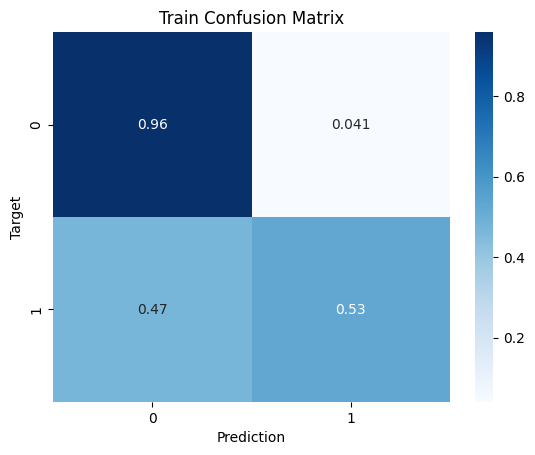

Area under ROC score on Validation dataset: 0.8828


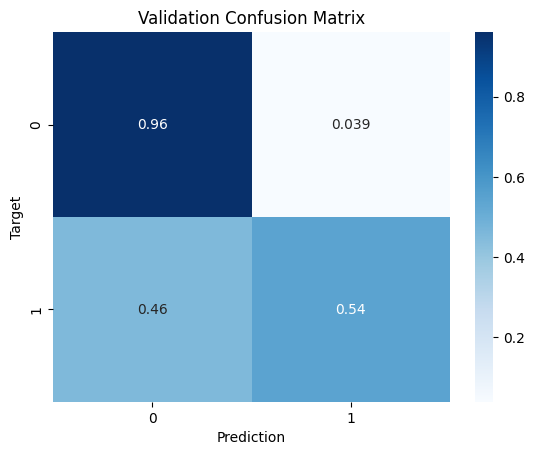

['log_reg.joblib']

In [3]:
# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[2:-1]
target_col = list(raw_df.columns)[-1]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='str').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.4f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg.joblib')

In [4]:
from sklearn.metrics import classification_report

print("Звіт для моделі:")
print(classification_report(val_targets, val_preds))

Звіт для моделі:
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      2371
         1.0       0.79      0.54      0.64       629

    accuracy                           0.87      3000
   macro avg       0.84      0.75      0.78      3000
weighted avg       0.87      0.87      0.86      3000



**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [5]:
from sklearn.preprocessing import PolynomialFeatures

Area under ROC score on Train dataset: 0.9231


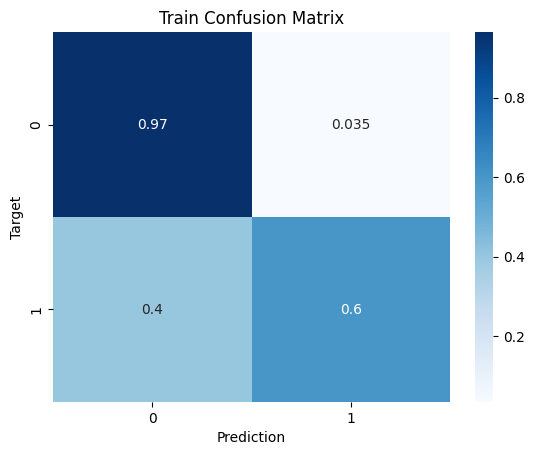

Area under ROC score on Validation dataset: 0.9141


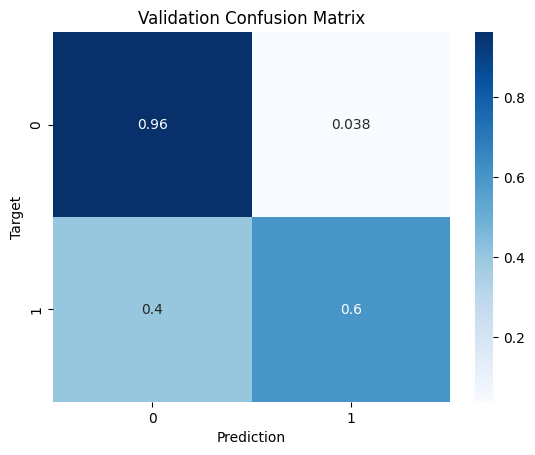

In [6]:
numeric_poly_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_poly_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо новий пайплайн
model_pipeline_poly.fit(train_inputs, train_targets)

# Оцінюємо модель на трен і вал даних
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

In [19]:
print("Звіт для Poly Degree 2:")
print('Train')
print(classification_report(train_targets, train_preds_poly))
print('Valid')
print(classification_report(val_targets, val_preds_poly))

Звіт для Poly Degree 2:
Train
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.93      9577
         1.0       0.81      0.60      0.69      2423

    accuracy                           0.89     12000
   macro avg       0.86      0.78      0.81     12000
weighted avg       0.89      0.89      0.89     12000

Valid
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93      2371
         1.0       0.81      0.60      0.69       629

    accuracy                           0.89      3000
   macro avg       0.85      0.78      0.81      3000
weighted avg       0.88      0.89      0.88      3000



**Спостереження**
- Модель з поліноміальними ознаками 2-го степеня краща (AUROC на валідаційному наборі 91% проти 88%).
- Underfit та Overfit немає - метрики на валідаційному наборі даних майже дорівнюють на тренувальному.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.9349


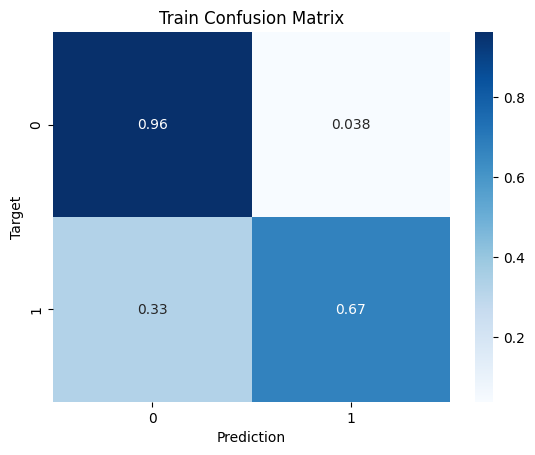

Area under ROC score on Validation dataset: 0.9213


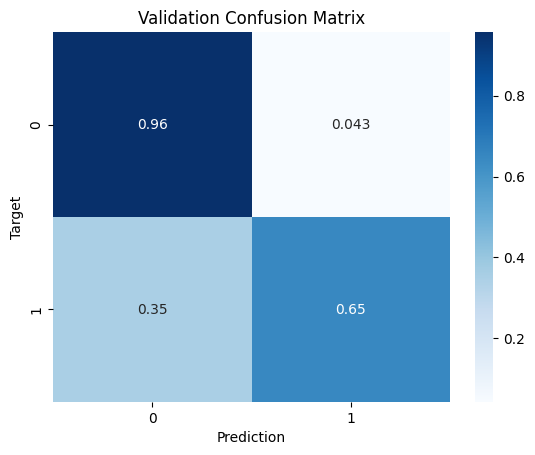

In [14]:
numeric_poly4_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4))
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_poly4_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо новий пайплайн
model_pipeline_poly4.fit(train_inputs, train_targets)

# Оцінюємо модель на трен і вал даних
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')

In [21]:
print("Звіт для Poly Degree 4:")
print('Train')
print(classification_report(train_targets, train_preds_poly4))
print('Val')
print(classification_report(val_targets, val_preds_poly4))

Звіт для Poly Degree 4:
Train
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      9577
         1.0       0.82      0.67      0.74      2423

    accuracy                           0.90     12000
   macro avg       0.87      0.82      0.84     12000
weighted avg       0.90      0.90      0.90     12000

Val
              precision    recall  f1-score   support

         0.0       0.91      0.96      0.93      2371
         1.0       0.80      0.65      0.72       629

    accuracy                           0.89      3000
   macro avg       0.86      0.80      0.82      3000
weighted avg       0.89      0.89      0.89      3000



**Спостереження**
- Модель з поліноміальними фічами степеня 4 показала ще кращі значення метрик. Але вона "складніша", бо містить більше колонок.
- Оскільки задача завдання найточніше передбачити, то буду сабмітити дані з останньою найточнішою моделлю.

In [24]:
test_raw_df = pd.read_csv("C:/Users/Ivanna/Documents/Dataset/bank-customer-churn-prediction-dlu-course-c-4/test.csv")
submission_df = pd.read_csv("C:/Users/Ivanna/Documents/Dataset/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv")

In [26]:
test_inputs = test_raw_df[input_cols]
test_preds_proba = model_pipeline_poly4.predict_proba(test_inputs)[:, 1]

In [28]:
test_raw_df['Exited'] = test_preds_proba
submission_log_reg = submission_df[['id']].merge(test_raw_df[['id', 'Exited']], on='id')
submission_log_reg.to_csv('submission_log_reg.csv', index=False)

In [30]:
submission_log_reg.head()

,id,Exited
0,15000,0.077211
1,15001,0.020049
2,15002,0.067775
3,15003,0.414973
4,15004,0.027020


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [126]:
df = pd.read_csv("C:/Users/Ivanna/Documents/Dataset/regression_data.csv")
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [115]:
df.isna().sum()

feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
target       0
dtype: int64

In [127]:
X = df.drop(columns='target')
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
model_poly_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=5, include_bias=False)),
    ('regressor', LinearRegression())
])

model_poly_pipeline.fit(X_train, y_train)
y_pred_train_poly = model_poly_pipeline.predict(X_train)
y_pred_test_poly = model_poly_pipeline.predict(X_test)
    
# Оцінка моделей
rmse_poly_train = root_mean_squared_error(y_train, y_pred_train_poly)
rmse_poly_test = root_mean_squared_error(y_test, y_pred_test_poly)

print(f"Train RMSE: {rmse_poly_train}")
print(f"Test RMSE: {rmse_poly_test}")

Train RMSE: 4.1243656266959363e-13
Test RMSE: 17.34875838106426


**Спостереження**
- Модель перенавчена, помилка на тренувальних практично 0, а на тестових 17.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [130]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

models = [
    LinearRegression(),
    Ridge(),
    Ridge(alpha=2),
    Lasso(),
    Lasso(alpha=0.5),
    Lasso(alpha=2),
    ElasticNet(),
    ElasticNet(alpha=0.5),
    ElasticNet(alpha=2)
]

In [139]:
def evaluate_model(regressor, X_train, y_train, X_test, y_test, degree):
    model_pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('polynomial', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', regressor)
    ])

    model_pipeline.fit(X_train, y_train)
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)
    
    # Оцінка моделей
    train_metrics = round(root_mean_squared_error(y_train, y_train_pred), 6)
    test_metrics = round(root_mean_squared_error(y_test, y_test_pred), 6)
    return dict(model_=str(regressor),
                rmse_train=train_metrics, 
                rmse_test=test_metrics)    

In [146]:
trained_pipelines = [] # створюємо список для збереження

for regressor in models:
    # Тренуємо
    pipe = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('polynomial', PolynomialFeatures(degree=20, include_bias=False)),
        ('regressor', regressor)
    ])
    pipe.fit(X_train, y_train)
    
    # Зберігаємо натренований об'єкт
    trained_pipelines.append(pipe)
    
    # Виводимо метрики
    print(evaluate_model(regressor, X_train, y_train, X_test, y_test, 20))

{'model_': 'LinearRegression()', 'rmse_train': 0.0, 'rmse_test': 12.734214}
{'model_': 'Ridge()', 'rmse_train': 5.885065, 'rmse_test': 7.02105}
{'model_': 'Ridge(alpha=2)', 'rmse_train': 7.92074, 'rmse_test': 8.614413}
{'model_': 'Lasso()', 'rmse_train': 5.098171, 'rmse_test': 5.671931}
{'model_': 'Lasso(alpha=0.5)', 'rmse_train': 2.718315, 'rmse_test': 2.91553}
{'model_': 'Lasso(alpha=2)', 'rmse_train': 10.019971, 'rmse_test': 11.278308}
{'model_': 'ElasticNet()', 'rmse_train': 30.034532, 'rmse_test': 30.442414}
{'model_': 'ElasticNet(alpha=0.5)', 'rmse_train': 23.835943, 'rmse_test': 23.298833}
{'model_': 'ElasticNet(alpha=2)', 'rmse_train': 36.138249, 'rmse_test': 38.582766}


**Спостереження**
- Lasso(alpha=0.5) має найменше значення RMSE для обох наборів даних. Треба додатковий аналіз по коеф, щоб перевірити які вона занулила.
- ElasticNet незалежно від значення alpha має максимальне значення похибки серед усіх регресорів.

In [153]:
trained_pipelines

[Pipeline(steps=[('scaler', MinMaxScaler()),
                 ('polynomial',
                  PolynomialFeatures(degree=20, include_bias=False)),
                 ('regressor', LinearRegression())]),
 Pipeline(steps=[('scaler', MinMaxScaler()),
                 ('polynomial',
                  PolynomialFeatures(degree=20, include_bias=False)),
                 ('regressor', Ridge())]),
 Pipeline(steps=[('scaler', MinMaxScaler()),
                 ('polynomial',
                  PolynomialFeatures(degree=20, include_bias=False)),
                 ('regressor', Ridge(alpha=2))]),
 Pipeline(steps=[('scaler', MinMaxScaler()),
                 ('polynomial',
                  PolynomialFeatures(degree=20, include_bias=False)),
                 ('regressor', Lasso())]),
 Pipeline(steps=[('scaler', MinMaxScaler()),
                 ('polynomial',
                  PolynomialFeatures(degree=20, include_bias=False)),
                 ('regressor', Lasso(alpha=0.5))]),
 Pipeline(steps=[('scal

In [163]:
# Вибираємо потрібний пайплайн зі списку Lasso 0.5)
lasso_pipe = trained_pipelines[4] 

# Витягуємо назви ознак та коефіцієнти
feature_names = lasso_pipe.named_steps['polynomial'].get_feature_names_out(X_train.columns)
weights = lasso_pipe.named_steps['regressor'].coef_

lasso_df = pd.DataFrame({
    'feature': feature_names,
    'coef': weights
})

# Залишаємо тільки ті, що НЕ дорівнюють нулю
active_features = lasso_df[lasso_df['coef'] != 0].sort_values(by='coef', ascending=False)

print(f"Lasso вибрала {len(active_features)} важливих ознак.")
print(active_features)

Lasso вибрала 1 важливих ознак.
     feature        coef
3  feature_4  207.330658


In [158]:
df.corr().round(4)

,feature_1,feature_2,feature_3,feature_4,feature_5,target
feature_1,1.0000,0.0903,0.0682,0.0057,0.1129,0.0075
feature_2,0.0903,1.0000,-0.0319,-0.0501,0.0753,-0.0500
feature_3,0.0682,-0.0319,1.0000,-0.0437,0.0168,-0.0429
feature_4,0.0057,-0.0501,-0.0437,1.0000,-0.1519,0.9997
feature_5,0.1129,0.0753,0.0168,-0.1519,1.0000,-0.1551
target,0.0075,-0.0500,-0.0429,0.9997,-0.1551,1.0000


**Спостереження**
- Модель Lasso не обнулила тільки ознаку  `feature_4`.
- Матриця кореляції підтверджує, що серед 5 ознак сильний зв'язок з таргет змінною є лише у `feature_4`. У всіх інших значення кореляції близьке до 0.
- Можна стверджувати що модель Lasso(alpha=0.5) найкраще генералізує.